# 2026-03 - Replicating `srtree-eqsat` in Egglog

This notebook summarizes the current baseline-only replication of the
`srtree-eqsat` equality-saturation pipeline from de Franca and Kronberger
(2023) in Egglog.

It is intentionally self-contained:
- it reads precomputed corpus results from
  `python/exp/srtree_eqsat/corpus_baseline_rows.csv`
- it does not shell out to a local `srtree-eqsat` checkout
- all conclusions are computed from the loaded corpus data at runtime

Offline regeneration commands from the repository root:
- `uv run --project . python python/exp/srtree_eqsat/compare_all_rows.py`

The executed notebook shown in GitHub is generated from this `py:light` file.

In [1]:
from __future__ import annotations

from io import BytesIO
from pathlib import Path

import matplotlib as mpl

mpl.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import Image, Markdown, display
except ImportError:  # pragma: no cover

    def Markdown(text: str) -> str:  # type: ignore[misc]
        return text

    Image = None

    def display(obj: object) -> None:  # pragma: no cover
        print(obj)


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "python" / "egglog").exists():
            return candidate
    msg = f"Could not locate egg-smol-python repo root from {start}"
    raise FileNotFoundError(msg)


def show_figure() -> None:
    figure = plt.gcf()
    if Image is None:  # pragma: no cover
        print(figure)
    else:
        buffer = BytesIO()
        figure.savefig(buffer, format="png", bbox_inches="tight")
        buffer.seek(0)
        display(Image(data=buffer.getvalue(), format="png"))
    plt.close(figure)


REPO_ROOT = find_repo_root(Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd().resolve())
CSV_PATH = REPO_ROOT / "python" / "exp" / "srtree_eqsat" / "corpus_baseline_rows.csv"
if not CSV_PATH.exists():
    msg = f"Missing corpus artifact: {CSV_PATH}"
    raise FileNotFoundError(msg)

data = pd.read_csv(CSV_PATH, keep_default_na=False)
for column in [
    "egglog_runtime_s",
    "haskell_runtime_s",
    "egglog_before_params",
    "egglog_after_params",
    "haskell_before_params",
    "haskell_after_params",
    "optimal_params",
    "egglog_gap_to_optimal",
    "haskell_gap_to_optimal",
    "egglog_total_size",
    "egglog_node_count",
    "egglog_eclass_count",
    "haskell_after_nodes",
]:
    data[column] = pd.to_numeric(data[column].replace("na", pd.NA), errors="coerce")

comparable = data[data["haskell_status"] == "ok"].copy()
mismatches = comparable[
    (comparable["egglog_before_params"] != comparable["haskell_before_params"])
    | (comparable["egglog_after_params"] != comparable["haskell_after_params"])
].copy()
optimal_rows = data[data["optimal_params"].notna()].copy()
haskell_ok = comparable.copy()
haskell_failures = data[data["haskell_status"] != "ok"].copy()
egglog_non_saturated = data[data["egglog_status"] != "saturated"].copy()
domain_limited = data[data["egglog_numeric_status"] != "ok"].copy()

## 1. What This Reproduces

The source corpus is `test/example_hl` from `srtree-eqsat`. The baseline
Egglog translation keeps the same Haskell pipeline shape:
- constant analysis over the expression language
- `rewritesBasic`
- `constReduction`
- `constFusion`
- `rewritesFun`
- the same backoff scheduling strategy used in the Haskell source

The comparison here is not against the paper's external SR systems directly.
It is an implementation-level replication check: does Egglog behave similarly
to the source Haskell EqSat implementation on the same `example_hl` corpus?

In [2]:
summary_lines = [
    f"- Rows in the corpus: `{len(data)}`",
    f"- Rows where the Haskell implementation completed: `{len(haskell_ok)}`",
    f"- Rows where the Haskell implementation failed: `{len(haskell_failures)}`",
    f"- Rows where Egglog reported saturation: `{int((data['egglog_status'] == 'saturated').sum())}`",
    f"- Rows where Egglog did not saturate under the current cutoff/budget: `{len(egglog_non_saturated)}`",
    f"- Rows with a domain-limited numeric check: `{len(domain_limited)}`",
]
display(Markdown("## Corpus Overview\n\n" + "\n".join(summary_lines)))

## Corpus Overview

- Rows in the corpus: `657`
- Rows where the Haskell implementation completed: `651`
- Rows where the Haskell implementation failed: `6`
- Rows where Egglog reported saturation: `655`
- Rows where Egglog did not saturate under the current cutoff/budget: `2`
- Rows with a domain-limited numeric check: `2`

## 2. Corpus-Level Comparison

The table below is the per-row comparison requested for the full corpus:
Haskell time, Egglog time, the final parameter count from each, and the
estimated minimal parameter count from the numeric Jacobian rank.

In [3]:
comparison_table = data[
    [
        "row",
        "haskell_runtime_s",
        "egglog_runtime_s",
        "haskell_after_params",
        "egglog_after_params",
        "optimal_params",
        "haskell_status",
        "egglog_status",
    ]
].copy()
display(comparison_table)

,row,haskell_runtime_s,egglog_runtime_s,haskell_after_params,egglog_after_params,optimal_params,haskell_status,egglog_status
0,1,0.001530,0.024019,2.0,2,2.0,ok,saturated
1,2,0.045319,0.024987,18.0,18,21.0,ok,saturated
2,3,0.192393,0.026963,17.0,17,19.0,ok,saturated
3,4,0.061409,0.026624,16.0,16,19.0,ok,saturated
4,5,0.203511,0.023930,14.0,15,15.0,ok,saturated
...,...,...,...,...,...,...,...,...
652,653,0.001489,0.010217,4.0,4,4.0,ok,saturated
653,654,0.001484,0.009963,4.0,4,4.0,ok,saturated
654,655,0.001118,0.010877,3.0,3,3.0,ok,saturated
655,656,0.001022,0.009824,3.0,3,3.0,ok,saturated


## 3. Data-Derived Findings

In [4]:
egglog_total = data["egglog_runtime_s"].sum()
egglog_median = data["egglog_runtime_s"].median()
haskell_total = haskell_ok["haskell_runtime_s"].sum()
haskell_median = haskell_ok["haskell_runtime_s"].median()
optimal_egglog = int((optimal_rows["egglog_gap_to_optimal"] == 0).sum())
optimal_haskell = int((optimal_rows["haskell_gap_to_optimal"] == 0).sum())
mismatch_rate = (len(mismatches) / len(haskell_ok)) if len(haskell_ok) else 0.0

display(
    Markdown(
        "\n".join([
            "## High-Level Findings",
            "",
            f"- On comparable rows, Egglog and Haskell disagree on parameter counts for `{len(mismatches)}` of `{len(haskell_ok)}` rows (`{mismatch_rate:.1%}`).",
            f"- Egglog total runtime across the corpus is `{egglog_total:.3f}s`; Haskell total runtime on successful rows is `{haskell_total:.3f}s`.",
            f"- Egglog median per-row runtime is `{egglog_median:.4f}s`; Haskell median per-row runtime is `{haskell_median:.4f}s`.",
            f"- Egglog reaches the estimated optimal parameter count on `{optimal_egglog}` rows with a valid optimal estimate; Haskell does so on `{optimal_haskell}` such rows.",
            f"- The Haskell implementation failed on rows `{', '.join(str(int(row)) for row in haskell_failures['row']) or 'none'}`.",
            f"- Egglog did not saturate on rows `{', '.join(str(int(row)) for row in egglog_non_saturated['row']) or 'none'}` under the current cutoff and iteration budget.",
        ])
    )
)

## High-Level Findings

- On comparable rows, Egglog and Haskell disagree on parameter counts for `60` of `651` rows (`9.2%`).
- Egglog total runtime across the corpus is `13.831s`; Haskell total runtime on successful rows is `75.193s`.
- Egglog median per-row runtime is `0.0213s`; Haskell median per-row runtime is `0.0113s`.
- Egglog reaches the estimated optimal parameter count on `335` rows with a valid optimal estimate; Haskell does so on `313` such rows.
- The Haskell implementation failed on rows `57, 165, 240, 322, 511, 624`.
- Egglog did not saturate on rows `152, 481` under the current cutoff and iteration budget.

## 4. Plots

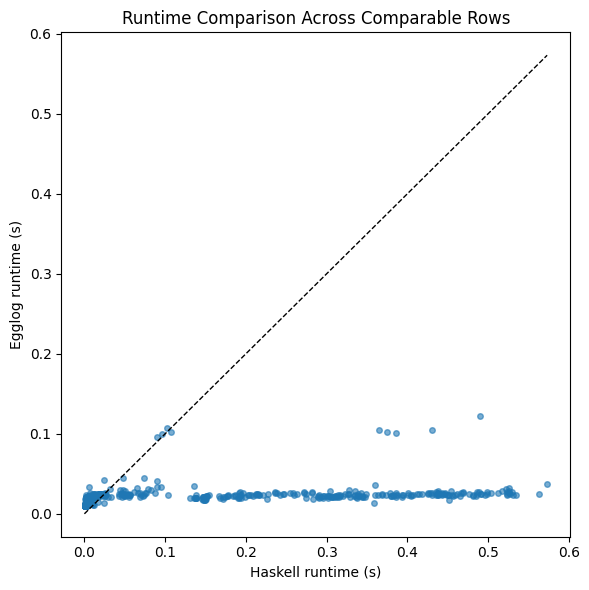

In [5]:
plt.figure(figsize=(6, 6))
plt.scatter(
    comparable["haskell_runtime_s"],
    comparable["egglog_runtime_s"],
    alpha=0.6,
    s=16,
)
max_runtime = max(comparable["haskell_runtime_s"].max(), comparable["egglog_runtime_s"].max())
plt.plot([0.0, max_runtime], [0.0, max_runtime], linestyle="--", color="black", linewidth=1.0)
plt.xlabel("Haskell runtime (s)")
plt.ylabel("Egglog runtime (s)")
plt.title("Runtime Comparison Across Comparable Rows")
plt.tight_layout()
show_figure()

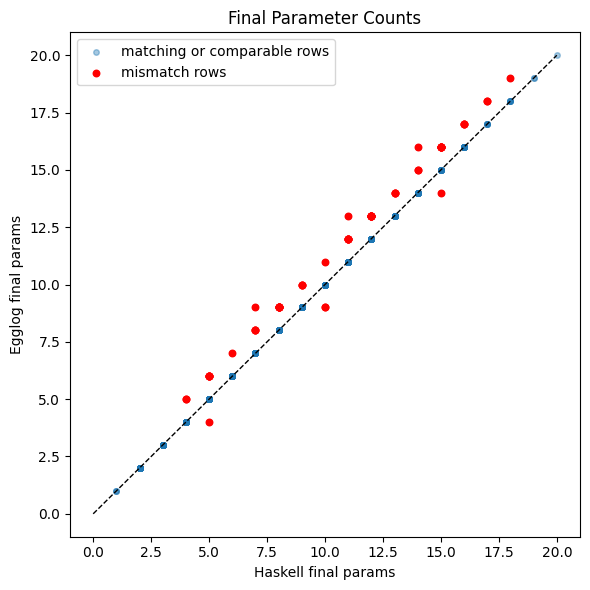

In [6]:
plt.figure(figsize=(6, 6))
plt.scatter(
    comparable["haskell_after_params"],
    comparable["egglog_after_params"],
    alpha=0.4,
    s=16,
    label="matching or comparable rows",
)
if not mismatches.empty:
    plt.scatter(
        mismatches["haskell_after_params"],
        mismatches["egglog_after_params"],
        color="red",
        s=22,
        label="mismatch rows",
    )
max_params = max(comparable["haskell_after_params"].max(), comparable["egglog_after_params"].max())
plt.plot([0.0, max_params], [0.0, max_params], linestyle="--", color="black", linewidth=1.0)
plt.xlabel("Haskell final params")
plt.ylabel("Egglog final params")
plt.title("Final Parameter Counts")
plt.legend()
plt.tight_layout()
show_figure()

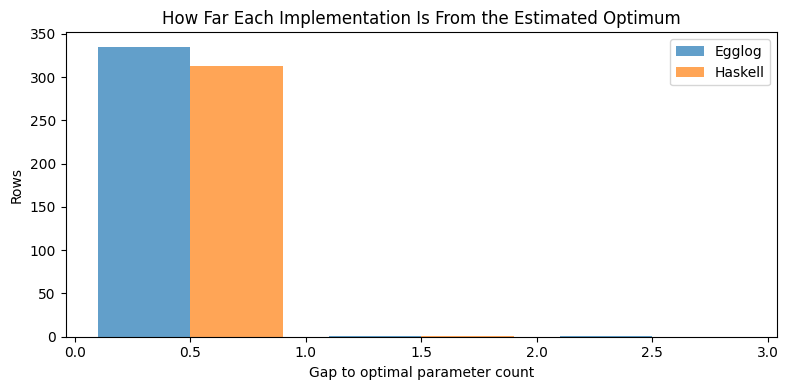

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(
    [
        optimal_rows["egglog_gap_to_optimal"].dropna(),
        optimal_rows["haskell_gap_to_optimal"].dropna(),
    ],
    bins=range(int(max(optimal_rows["egglog_gap_to_optimal"].max(), optimal_rows["haskell_gap_to_optimal"].max())) + 2),
    label=["Egglog", "Haskell"],
    alpha=0.7,
)
plt.xlabel("Gap to optimal parameter count")
plt.ylabel("Rows")
plt.title("How Far Each Implementation Is From the Estimated Optimum")
plt.legend()
plt.tight_layout()
show_figure()

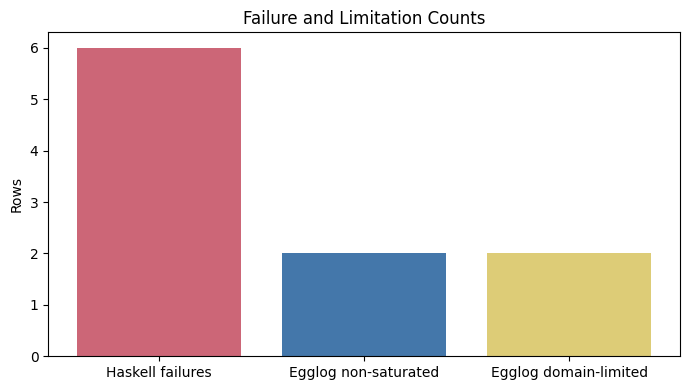

In [8]:
status_counts = pd.DataFrame({
    "category": [
        "Haskell failures",
        "Egglog non-saturated",
        "Egglog domain-limited",
    ],
    "count": [
        len(haskell_failures),
        len(egglog_non_saturated),
        len(domain_limited),
    ],
})
plt.figure(figsize=(7, 4))
plt.bar(status_counts["category"], status_counts["count"], color=["#cc6677", "#4477aa", "#ddcc77"])
plt.ylabel("Rows")
plt.title("Failure and Limitation Counts")
plt.tight_layout()
show_figure()

## 5. Rows Worth Inspecting

These are the rows where the baseline still differs from the Haskell result
or where the source implementation failed.

In [9]:
display(
    mismatches[
        [
            "row",
            "haskell_after_params",
            "egglog_after_params",
            "optimal_params",
            "haskell_runtime_s",
            "egglog_runtime_s",
            "egglog_output",
            "haskell_output",
        ]
    ]
)

,row,haskell_after_params,egglog_after_params,optimal_params,haskell_runtime_s,egglog_runtime_s,egglog_output,haskell_output
4,5,14.0,15,15.0,0.203511,0.023930,(((((2.98279150112649 + (-2.50335104760053 * a...,"(1.38844130555412 * ((np.exp((x[:, 0] * 0.4721..."
10,11,8.0,9,9.0,0.008713,0.021633,(((beta * ((((((-8.26890486627253 + (2.5898420...,"(((x[:, 1] * ((((-8.26890486627253 + (2.589842..."
44,45,16.0,17,18.0,0.271615,0.026719,((((((((exp((0.648490240977986 * alpha)) * ((-...,"((((((((np.exp((0.648490240977986 * x[:, 0])) ..."
45,46,15.0,16,18.0,0.235975,0.026765,((((((((exp((0.530572727218752 * alpha)) * ((-...,"(((((((np.exp((0.530572727218752 * x[:, 0])) *..."
46,47,15.0,16,17.0,0.238612,0.026531,((((((((exp((0.572325905005211 * alpha)) * ((-...,"(((((((np.exp((0.572325905005211 * x[:, 0])) *..."
47,48,15.0,16,17.0,0.191181,0.026344,((((((((exp((0.751844527789132 * alpha)) * ((-...,"((x[:, 1] * ((1.3120106695137943 + ((((np.log(..."
48,49,13.0,14,15.0,0.444081,0.024785,((((((((exp((0.730289703455073 * alpha)) * ((-...,(((4.584825222247909 + (((-1.26994653674891 - ...
49,50,12.0,13,14.0,0.020114,0.023976,((((((((exp((0.743694003014863 * alpha)) * ((-...,"(((6.5874389967108335 + ((np.exp((x[:, 2] * -0..."
120,121,5.0,6,7.0,0.046240,0.021246,(((alpha * (-2.21157607162553 + (((-0.95334344...,"((x[:, 0] * (((((-0.953343448548115 * x[:, 2])..."
135,136,10.0,11,11.0,0.012225,0.021812,(((((((sqrt(exp((1.75803021534004 * alpha))) *...,((((((((np.sqrt(np.exp((1.75803021534004 * x[:...


In [10]:
display(
    data[data["haskell_status"] != "ok"][
        [
            "row",
            "haskell_status",
            "haskell_runtime_s",
            "egglog_after_params",
            "optimal_params",
            "input_expr",
        ]
    ]
)

,row,haskell_status,haskell_runtime_s,egglog_after_params,optimal_params,input_expr
56,57,failed,24.433494,8,9.0,((-0.915483354984599 * theta + 0.2734838841613...
164,165,failed,21.021734,4,5.0,(log(1.01868777466806 * theta) - 0.34130306102...
239,240,failed,21.268568,10,11.0,(exp(0.0843923652197984 * theta) + -13.5224391...
321,322,failed,27.538149,15,16.0,(sqr(2.24845855590462 - 0.370543772479144 * th...
510,511,failed,23.631988,8,9.0,-1.21291860929665 * beta / exp(-0.503773882760...
623,624,failed,24.024479,12,12.0,(-0.292224015955952 * alpha + 2.0638020644789 ...


## 6. Current Limitations

The current baseline results show where the replication is close to the source
implementation and where it still falls short.

In [11]:
egglog_wins = int((comparable["egglog_after_params"] < comparable["haskell_after_params"]).sum())
haskell_wins = int((comparable["egglog_after_params"] > comparable["haskell_after_params"]).sum())
both_above_optimal = int(
    (
        (optimal_rows["egglog_gap_to_optimal"].fillna(0) > 0) & (optimal_rows["haskell_gap_to_optimal"].fillna(0) > 0)
    ).sum()
)
egglog_below_estimate = int((optimal_rows["egglog_gap_to_optimal"].fillna(0) < 0).sum())
haskell_below_estimate = int((optimal_rows["haskell_gap_to_optimal"].fillna(0) < 0).sum())

display(
    Markdown(
        "\n".join([
            "## Current Limitations",
            "",
            f"- Egglog still finishes with more parameters than Haskell on `{haskell_wins}` comparable rows; Egglog finishes with fewer on `{egglog_wins}` rows.",
            f"- Both implementations remain above the estimated optimal parameter count on `{both_above_optimal}` rows with a valid optimal estimate.",
            f"- The Haskell implementation failed on `{len(haskell_failures)}` rows, so the comparison corpus is not fully comparable end to end.",
            f"- Egglog did not saturate on `{len(egglog_non_saturated)}` rows under the current cutoff and iteration budget.",
            f"- The numeric-rank estimate is not acting like a strict lower bound in every case: Egglog lands below that estimate on `{egglog_below_estimate}` rows and Haskell does so on `{haskell_below_estimate}` rows.",
        ])
    )
)

## Current Limitations

- Egglog still finishes with more parameters than Haskell on `56` comparable rows; Egglog finishes with fewer on `4` rows.
- Both implementations remain above the estimated optimal parameter count on `1` rows with a valid optimal estimate.
- The Haskell implementation failed on `6` rows, so the comparison corpus is not fully comparable end to end.
- Egglog did not saturate on `2` rows under the current cutoff and iteration budget.
- The numeric-rank estimate is not acting like a strict lower bound in every case: Egglog lands below that estimate on `312` rows and Haskell does so on `329` rows.